In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("credit_card_fraud.csv")

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nFirst Five Rows:")
display(df.head())

Shape of Dataset: (10000, 10)

Column Names:
Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Duplicate Rows: 0


In [5]:
df.describe(include='all')

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Food,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2093,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,175.949849,11.593300,NaN,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,NaN,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,NaN,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,NaN,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,NaN,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,NaN,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000


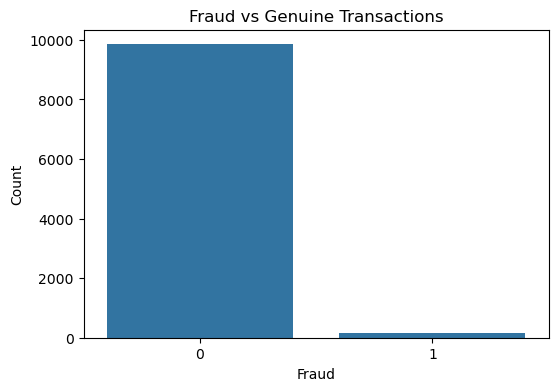

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Genuine Transactions")

plt.xlabel("Fraud")

plt.ylabel("Count")

plt.show()

print(df['is_fraud'].value_counts())

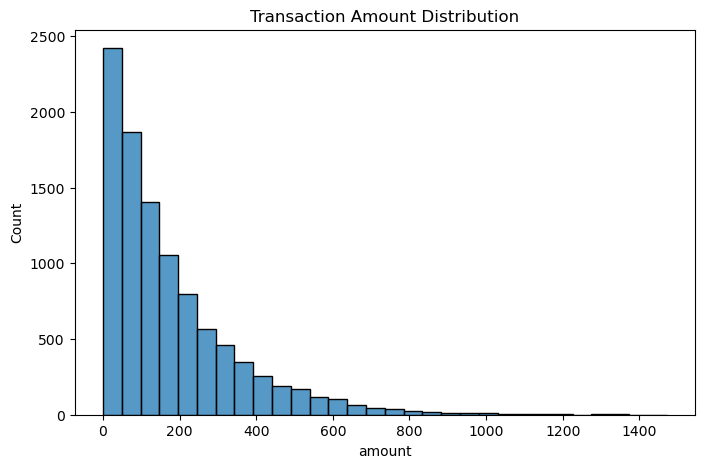

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=30)

plt.title("Transaction Amount Distribution")

plt.show()

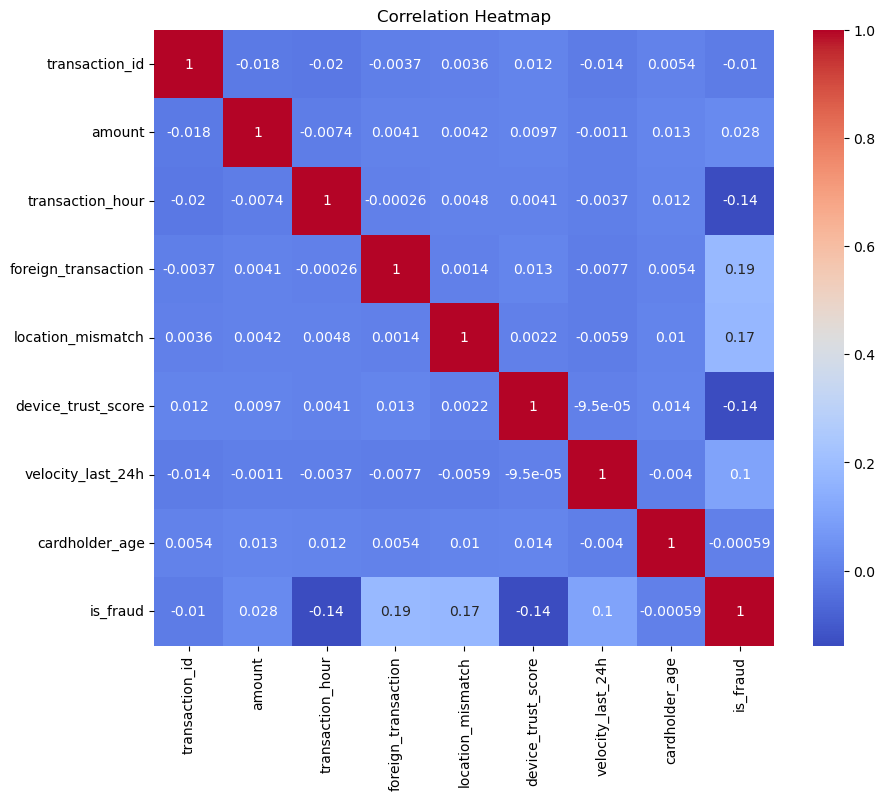

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [9]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,1,0,0,66,3,40,0
1,2,541.82,3,4,1,0,87,1,64,0
2,3,237.01,17,3,0,0,49,1,61,0
3,4,164.33,4,3,0,1,72,3,34,0
4,5,30.53,15,2,0,0,79,0,44,0


In [10]:
X = df.drop(["is_fraud", "transaction_id"], axis=1)

y = df["is_fraud"]

print(X.head())

print(y.head())

   amount  transaction_hour  merchant_category  foreign_transaction  \
0   84.47                22                  1                    0   
1  541.82                 3                  4                    1   
2  237.01                17                  3                    0   
3  164.33                 4                  3                    0   
4   30.53                15                  2                    0   

   location_mismatch  device_trust_score  velocity_last_24h  cardholder_age  
0                  0                  66                  3              40  
1                  0                  87                  1              64  
2                  0                  49                  1              61  
3                  1                  72                  3              34  
4                  0                  79                  0              44  
0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(pd.Series(y_train_smote).value_counts())

Before SMOTE
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [13]:
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = rf_model.predict(X_test_scaled)

y_prob = rf_model.predict_proba(X_test_scaled)[:,1]

In [16]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9745
Precision : 0.3561643835616438
Recall : 0.8666666666666667
F1 Score : 0.5048543689320388
ROC-AUC : 0.9897038917089678


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.36      0.87      0.50        30

    accuracy                           0.97      2000
   macro avg       0.68      0.92      0.75      2000
weighted avg       0.99      0.97      0.98      2000



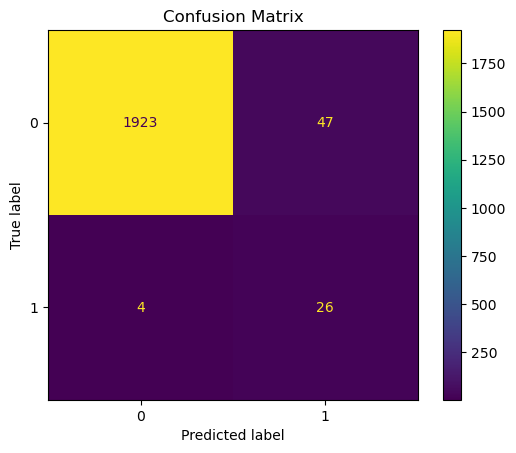

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

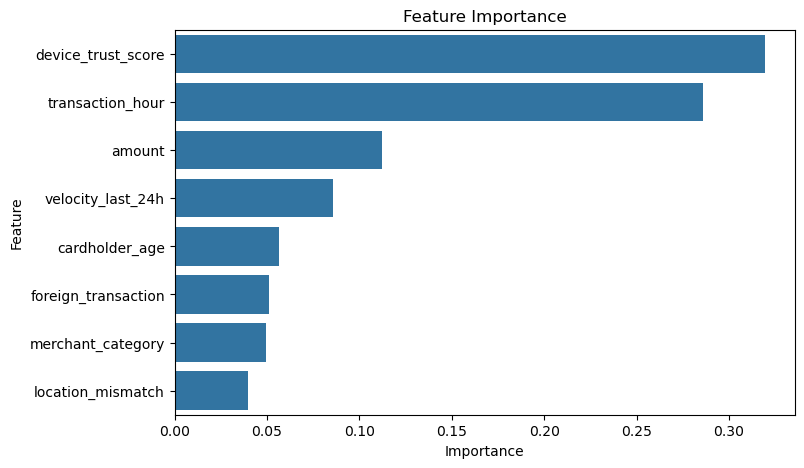

,Feature,Importance
5,device_trust_score,0.319529
1,transaction_hour,0.286036
0,amount,0.112397
6,velocity_last_24h,0.085726
7,cardholder_age,0.056519
3,foreign_transaction,0.050990
2,merchant_category,0.049166
4,location_mismatch,0.039638


In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

importance

In [20]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X_train_smote)

pred = iso.predict(X_test_scaled)

pred = np.where(pred == -1, 1, 0)

print("Isolation Forest Accuracy:",
      accuracy_score(y_test, pred))

Isolation Forest Accuracy: 0.935


In [21]:
joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [23]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = rf_model.predict(sample_scaled)

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Legitimate Transaction")

Legitimate Transaction
